In [1]:
import os
import django

os.environ.setdefault("DJANGO_SETTINGS_MODULE", "config.settings")
django.setup()

In [ ]:
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_core.messages import AIMessage,SystemMessage,HumanMessage
from pydantic import BaseModel,Field
from typing import Literal,Optional,List
from langgraph.graph import START,END,StateGraph
import operator
from langchain_core.tools import tool
from salon.models import Staff, Service, Client, Appointment
from datetime import timedelta
from django.utils import timezone
import datetime



In [3]:
load_dotenv()

True

In [4]:
model = ChatGroq(model="llama-3.3-70b-versatile")

## State of WorkFlow

In [5]:
class State:
    usr_msg: str
    msg_category: str
    
    ## State for booking
    client_name : str
    client_phone : str
    response : Optional[str]
    booking_context : dict
    escalate : bool
    history: List[dict] # for short term memory taa k LLM context bhule nhi 
    

## Node 1 - Classify Message

### Pydantic Schema

In [6]:
class messageClassification(BaseModel):
    category : Literal["booking","faq","reschedule","other"]
    confidence: Literal["low","high"]

### Making LLM aware of schema

In [7]:
structured_model = model.with_structured_output(messageClassification,strict = True)

### Defining Node

In [8]:
def message_classification_node(state: State):
    message = state['usr_msg']
    message_classification_prompt = """You are an intent classifier for a clinic/salon WhatsApp receptionist agent.
        Classify the customer's message into EXACTLY ONE of these categories:

        - booking: customer wants to schedule a NEW appointment
        - faq: customer is asking a question (timings, pricing, location, services offered, doctor availability)
        - reschedule: customer wants to change or cancel an EXISTING appointment
        - other: greetings, unclear messages, or anything not covered above (will be escalated to human staff)

        Rules:
        - If the message mixes a greeting with a request (e.g. "Hi, mujhe appointment chahiye"), classify by the REQUEST, not the greeting.
        - If the message is ambiguous between booking and faq (e.g. "facial ka kya rate hai, book bhi karna hai"), classify as booking since that's the actionable intent.
        - Cancellation requests count as reschedule, not other.
        - Respond with ONLY the category word. No explanation, no punctuation.

        Examples:
        Message: "Kal 3 baje slot mil sakta hai facial ke liye?"
        Category: booking

        Message: "Aap log kitne baje tak khule hote hain?"
        Category: faq

        Message: "Mera appointment kal ka tha, main aaj aana chahta hoon"
        Category: reschedule

        Message: "Mera appointment cancel kar dein please"
        Category: reschedule

        Message: "Salam"
        Category: other

        Message: "Facial ka price kya hai aur kal available hai kya?"
        Category: booking

        Now classify this message:
        Message: "{message}"
        Category:"""

    result = structured_model.invoke( [
            SystemMessage(content = message_classification_prompt),
            HumanMessage(content=message)
            ]
            
        )
    state['msg_Category'] = result.category if result.confidence == "high" else "other"
    print(state)
    return state
    

## Creating the Router Function

In [9]:
def router(state:State)-> Literal['faq_node','booking_node','reschedule_node','others_node']:
    category = state.get('msg_Category','other')
    if category == "booking":
        return 'booking_node'
    elif category == "faq":
        return 'faq_node'
    elif category == "reschedule":
        return 'reschedule_node'
    else:
        return 'others_node'

## 2- Booking Node

### Helper Function ----- Generate Slots

In [14]:
def generate_slots(start_time, end_time, duration_minutes, date_str):
    """Working hours ke andar duration ke hisaab se possible slots banata hai."""
    date_obj = datetime.strptime(date_str, "%Y-%m-%d").date()
    current = timezone.make_aware(datetime.combine(date_obj, start_time))
    end_dt = timezone.make_aware(datetime.combine(date_obj, end_time))
    slots = []
    while current + timedelta(minutes=duration_minutes) <= end_dt:
        slots.append(current)
        current += timedelta(minutes=duration_minutes)
    return slots

### Creating Schema of check availabilty tool

In [11]:
class CheckAvailabilityInput(BaseModel):
    service_name: str = Field(description="Name of the service, e.g. 'facial', 'haircut'")
    preferred_date: str = Field(description="Date in YYYY-MM-DD format")

### Check Availabilty Tool

In [19]:
@tool(args_schema=CheckAvailabilityInput)
def check_availability(service_name: str, preferred_date: str) -> dict:
    """Check available appointment slots for a service on a given date.
    Use this ONLY after you know both the service name and the date."""
    service = Service.objects.filter(name__icontains=service_name).first()
    if not service:
        return {"error": f"'{service_name}' service not found"}

    available = []
    for staff in Staff.objects.all():
        booked_times = set(
            Appointment.objects.filter(
                staff=staff, start_time__date=preferred_date,
                status__in=["pending", "confirmed"]
            ).values_list("start_time", flat=True)
        )
        possible_slots = generate_slots(
            staff.working_hours_start, staff.working_hours_end,
            service.duration_minutes, preferred_date
        )
        free_slots = [s for s in possible_slots if s not in booked_times]
        if free_slots:
            available.append({"staff": staff.name, "slots": [str(s.time()) for s in free_slots[:3]]})

    if not available:
        return {"service": service.name, "date": preferred_date, "availability": [], "message": "No slots free that day"}

    return {"service": service.name, "date": preferred_date, "availability": available}

### Schema of check appointement tool

In [16]:
class CreateAppointmentInput(BaseModel):
    client_phone: str = Field(description="Customer's WhatsApp phone number")
    client_name: str = Field(description="Customer's name")
    staff_name: str = Field(description="Name of the staff member")
    service_name: str = Field(description="Name of the service")
    start_time: str = Field(description="Appointment start time in YYYY-MM-DDTHH:MM format")



### Create Appointment Tool

In [18]:
@tool(args_schema=CreateAppointmentInput)
def create_appointment(client_phone: str, client_name: str, staff_name: str,service_name: str, start_time: str) -> dict:
    """Book the appointment. ONLY call this after the customer has explicitly 
    confirmed a specific slot (e.g. said 'haan', 'confirm', 'theek hai')."""
    client, _ = Client.objects.get_or_create(phone=client_phone, defaults={"name": client_name})
    staff = Staff.objects.filter(name__icontains=staff_name).first()
    service = Service.objects.filter(name__icontains=service_name).first()
    if not staff or not service:
        return {"error": "Staff or service not found"}

    start = timezone.make_aware(datetime.fromisoformat(start_time))
    end = start + timedelta(minutes=service.duration_minutes)

    # race-check — koi aur isi beech mein slot na le chuka ho
    clash = Appointment.objects.filter(
        staff=staff, start_time__lt=end, end_time__gt=start,
        status__in=["pending", "confirmed"]
    ).exists()
    if clash:
        return {"error": "Slot just got booked by someone else, please choose another time"}

    appt = Appointment.objects.create(
        client=client, staff=staff, service=service,
        start_time=start, end_time=end, status="confirmed", booked_by_agent=True
    )
    return {"success": True, "appointment_id": appt.id, "time": start_time, "staff": staff.name}

### Making LLM aware of tool

In [20]:
booking_model = model.bind_tools([check_availability, create_appointment])


### Defining booking node

In [21]:
BOOKING_SYSTEM_PROMPT = """You are a booking assistant for a salon on WhatsApp.

Your job:
1. Use the conversation history and the new message to figure out the service, date, and time.
2. If something is missing, ask ONE short question for just that missing piece.
3. Once you have service + date + time, call check_availability.
4. Show the available slot(s) and ASK FOR EXPLICIT CONFIRMATION before booking.
   Never call create_appointment unless the customer has clearly confirmed.
5. After confirmation, call create_appointment.
6. Keep replies short, in the customer's language style (Roman Urdu/English mix is fine).

Client phone: {client_phone}
Client name: {client_name}
Today's date: {today}
"""

TOOL_MAP = {
    "check_availability": check_availability,
    "create_appointment": create_appointment,
}

def booking_node(state: State) -> State:
    system = BOOKING_SYSTEM_PROMPT.format(
        client_phone=state["client_phone"],
        client_name=state.get("client_name", "Unknown"),
        today=datetime.today().isoformat()
    )
    messages = [{"role": "system", "content": system}] + state["history"] + \
               [{"role": "user", "content": state["message"]}]

    response = booking_model.invoke(messages)

    if response.tool_calls:
        tool_results = []
        for call in response.tool_calls:
            fn = TOOL_MAP[call["name"]]
            try:
                result = fn.invoke(call["args"])
            except Exception as e:
                result = {"error": str(e)}
            tool_results.append({
                "role": "tool", "content": str(result), "tool_call_id": call["id"]
            })

        final = booking_model.invoke(messages + [response] + tool_results)
        state["response"] = final.content
    else:
        state["response"] = response.content

    return state

## Creating Graph

In [11]:
workflow = StateGraph(State)

# Adding Nodes 
workflow.add_node('message_classification_node',message_classification_node)

# Adding Edges
workflow.add_edge(START,'message_classification_node')
workflow.add_edge('message_classification_node',END)

graph = workflow.compile()


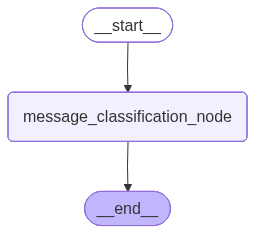

In [12]:
graph

In [16]:
test_state: State = {
    "usr_msg": "kya mein apni booked slot change krwa skty hun"}
res = graph.invoke(test_state)
print(res)

{'usr_msg': 'kya mein apni booked slot change krwa skty hun', 'msg_Category': 'reschedule'}
{'usr_msg': 'kya mein apni booked slot change krwa skty hun'}
